# Logistic Regression Model for Dementia Screening

**Project:** `ml_dementia`  
**Data:** `data.csv`  
**Purpose:** rehearse a leakage-aware, interpretable screening pipeline described in `plan.md`.

> **Important:** `data.csv` is fully synthetic. It contains no real patient records, and all results are illustrative pipeline-development outputs rather than findings about Zimbabwe.

## Analysis roadmap

1. Load and audit the raw data.
2. Explore distributions, missingness, outcome balance, and data-quality defects.
3. Clean sentinels, categories, dates, duplicates, impossible values, contradictions, and eligibility.
4. Split before fitting preprocessing; use train-only imputation and one-hot encoding.
5. Fit and evaluate a primary logistic regression without `cognitive_screen_score`.
6. Inspect odds ratios, calibration, subgroup performance, and an explicitly labelled leakage sensitivity analysis.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, f1_score,
    precision_recall_curve, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 100)

## 1. Load and audit raw data

In [2]:
DATA_PATH = Path('data.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path.cwd() / 'data.csv'
raw = pd.read_csv(DATA_PATH, na_values=['', 'NA', 'N/A', 'NULL'])
print(f'Loaded {raw.shape[0]:,} rows and {raw.shape[1]} columns from {DATA_PATH.resolve()}')
display(raw.head(3))
display(raw.dtypes.rename('dtype').to_frame())
display(raw.describe(include='all').T.head(12))

Loaded 12,168 rows and 31 columns from D:\Projects\ml_dementia\data.csv


,participant_id,interview_date,province,residence,sex,age_years,marital_status,education_years,employment_status,monthly_household_income_usd,lives_alone,social_engagement,hiv_status,hypertension_dx,takes_bp_medication,diabetes_dx,prior_stroke,head_injury_history,family_history_dementia,systolic_bp_mmhg,diastolic_bp_mmhg,bmi_kg_m2,gds15_score,hearing_difficulty,vision_difficulty,smoking_status,alcohol_use,physical_activity_level,fruit_veg_servings_per_day,cognitive_screen_score,dementia_status
0,ZW-00001,12/11/2024,Mashonaland West,Urban,F,62,Married,6.0,Unemployed,20.0,0,Daily,Negative,1,0.0,0,0,0.0,0.0,151.0,92.0,16.8,2.0,0.0,0.0,Never,NaN,High,2.0,25.0,0
1,ZW-00002,2024-05-12,Manicaland,Urban,F,61,Widowed,7.0,Retired,65.0,0,Daily,Negative,0,0.0,0,0,0.0,0.0,113.0,85.0,22.6,2.0,0.0,0.0,Never,NaN,Low,6.0,24.0,0
2,ZW-00003,23/02/2024,Harare,Urban,M,68,Widowed,NaN,Unemployed,45.0,1,Daily,Negative,0,0.0,0,0,0.0,0.0,99.0,90.0,21.1,4.0,0.0,0.0,Never,NaN,Low,4.0,25.0,0


,dtype
participant_id,str
interview_date,str
province,str
residence,str
sex,str
age_years,int64
marital_status,str
education_years,float64
employment_status,str
monthly_household_income_usd,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,12168,12000,ZW-00012,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
interview_date,12168,1339,2024-04-14,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
province,12168,42,Harare,2285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
residence,12168,8,Rural,7781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,12168,13,F,6419,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_years,12168.0,NaN,NaN,NaN,69.738823,37.751405,-5.0,62.0,65.0,71.0,999.0
marital_status,12048,20,Married,6347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_years,11929.0,NaN,NaN,NaN,2.778188,15.194445,-99.0,2.0,5.0,7.0,51.0
employment_status,12054,31,Retired,5730,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_household_income_usd,10428.0,NaN,NaN,NaN,103.80888,120.01265,0.0,35.0,65.0,120.0,800.0


### Raw data-quality inventory
The generator intentionally injects duplicate IDs, sentinel values, inconsistent labels, missingness, and impossible measurements. These checks make those defects visible before any repair.

In [3]:
raw_audit = pd.DataFrame({
    'missing': raw.isna().sum(),
    'missing_pct': (raw.isna().mean() * 100).round(2),
    'unique_values': raw.nunique(dropna=True),
}).sort_values('missing_pct', ascending=False)
display(raw_audit)
print(f"Duplicate participant IDs: {raw['participant_id'].duplicated(keep=False).sum():,}")
print('Sentinel counts:')
display(raw.astype('string').isin(['-99', '88', '99']).sum().loc[lambda s: s.gt(0)].to_frame('count'))

,missing,missing_pct,unique_values
alcohol_use,8015,65.87,14
monthly_household_income_usd,1740,14.30,151
diastolic_bp_mmhg,1194,9.81,103
systolic_bp_mmhg,631,5.19,132
bmi_kg_m2,438,3.60,212
gds15_score,395,3.25,16
takes_bp_medication,337,2.77,2
fruit_veg_servings_per_day,336,2.76,13
hearing_difficulty,267,2.19,2
cognitive_screen_score,258,2.12,19


Duplicate participant IDs: 336
Sentinel counts:


,count
age_years,73


## 2. Exploratory data analysis
EDA is performed on the raw import to show the impact and pattern of the engineered defects. The target is inspected before modelling, but never used to fit cleaning or preprocessing decisions.

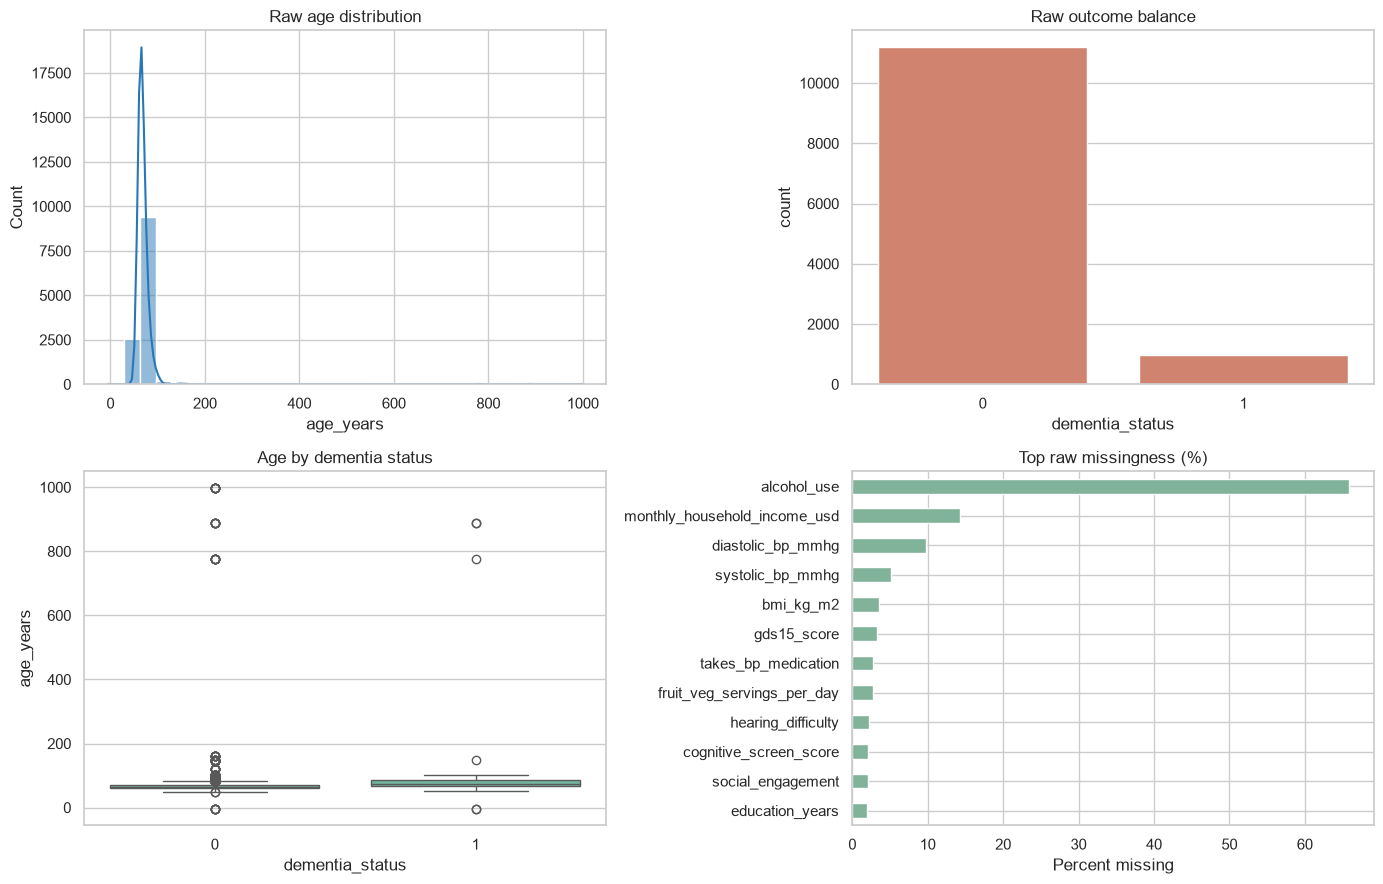

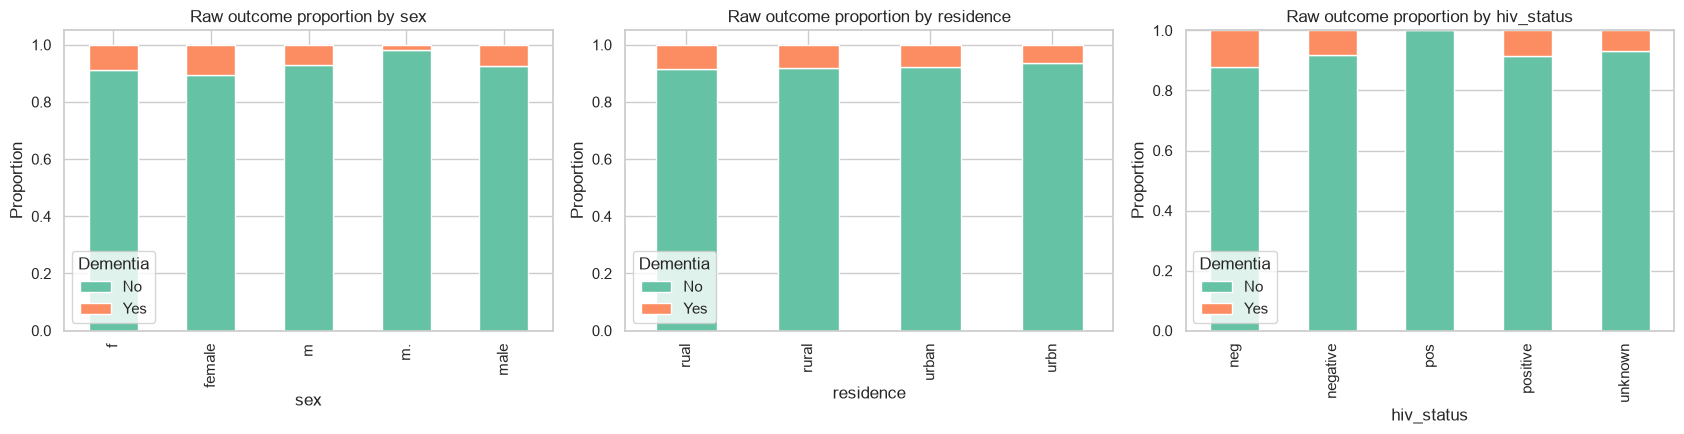

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(raw['age_years'], bins=30, kde=True, ax=axes[0, 0], color='#2878b5')
axes[0, 0].set_title('Raw age distribution')
sns.countplot(data=raw, x='dementia_status', ax=axes[0, 1], color='#e07a5f')
axes[0, 1].set_title('Raw outcome balance')
sns.boxplot(data=raw, x='dementia_status', y='age_years', ax=axes[1, 0])
axes[1, 0].set_title('Age by dementia status')
missing_top = raw.isna().mean().sort_values(ascending=False).head(12) * 100
missing_top.sort_values().plot.barh(ax=axes[1, 1], color='#81b29a')
axes[1, 1].set_title('Top raw missingness (%)')
axes[1, 1].set_xlabel('Percent missing')
plt.tight_layout()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for column, ax in zip(['sex', 'residence', 'hiv_status'], axes):
    pd.crosstab(raw[column].astype('string').str.strip().str.lower(), raw['dementia_status'], normalize='index').plot.bar(ax=ax, stacked=True)
    ax.set_title(f'Raw outcome proportion by {column}')
    ax.set_ylabel('Proportion')
    ax.legend(title='Dementia', labels=['No', 'Yes'])
plt.tight_layout()

## 3. Data cleaning
Cleaning rules follow `plan.md`: convert sentinels to missing, normalize controlled vocabularies, parse dates, keep one row per participant, reject impossible values as missing, flag contradictions, and apply the age eligibility rule. No outcome values are altered.

In [8]:
df = raw.copy()
# Treat survey sentinels as missing only in fields where they are invalid values.
sentinel_columns = df.columns.difference(['participant_id', 'dementia_status'])
for column in sentinel_columns:
    if pd.api.types.is_numeric_dtype(df[column]):
        df[column] = df[column].replace([-99, 88, 99], np.nan)
    else:
        df[column] = df[column].replace(['-99', '88', '99'], np.nan)

# Normalize whitespace/case first, then map known variants to controlled labels.
for column in df.select_dtypes(include='object').columns:
    df[column] = df[column].str.strip()

maps = {
    'sex': {'m': 'M', 'm.': 'M', 'male': 'M', 'f': 'F', 'female': 'F'},
    'residence': {'urban': 'Urban', 'urbn': 'Urban', 'rural': 'Rural', 'rual': 'Rural'},
    'hiv_status': {'positive': 'Positive', 'pos': 'Positive', 'negative': 'Negative', 'neg': 'Negative', 'unknown': 'Unknown'},
    'social_engagement': {'daily': 'Daily', 'weekly': 'Weekly', 'rarely': 'Rarely', 'never': 'Never'},
    'smoking_status': {'never': 'Never', 'never smoked': 'Never', 'none': 'Never', 'former': 'Former', 'ex-smoker': 'Former', 'ex smoker': 'Former', 'current': 'Current', 'current smoker': 'Current', 'yes': 'Current'},
    'alcohol_use': {'none': 'None', 'non': 'None', 'no': 'None', 'moderate': 'Moderate', 'light': 'Moderate', 'hazardous': 'Hazardous', 'heavy': 'Hazardous', 'heavy drinker': 'Hazardous'},
    'physical_activity_level': {'low': 'Low', 'moderate': 'Moderate', 'high': 'High'},
    'marital_status': {'maried': 'Married', 'married': 'Married', 'widwoed': 'Widowed', 'widow': 'Widowed', 'widowed': 'Widowed', 'divorced': 'Divorced/Separated', 'divorced/seperated': 'Divorced/Separated', 'divorced / separated': 'Divorced/Separated', 'divorced/separated': 'Divorced/Separated', 'single': 'Never Married', 'never married': 'Never Married', 'never-married': 'Never Married'},
    'employment_status': {'retired': 'Retired', 'subsistence farming': 'Subsistence Farming', 'subsistence farmer': 'Subsistence Farming', 'farming': 'Subsistence Farming', 'informal trade': 'Informal Trading', 'vendor': 'Informal Trading', 'informal trading': 'Informal Trading', 'formal': 'Formal Employment', 'formal sector': 'Formal Employment', 'formal employment': 'Formal Employment', 'unemployed': 'Unemployed', 'not employed': 'Unemployed'},
}
for column, mapping in maps.items():
    normalized = df[column].astype('string').str.lower()
    df[column] = normalized.map(mapping).fillna(df[column])

province_map = {
    'harare province': 'Harare', 'hre': 'Harare', 'harare': 'Harare',
    'bulawayo': 'Bulawayo', 'manicaland': 'Manicaland',
    'mashonaland central': 'Mashonaland Central', 'mash central': 'Mashonaland Central',
    'mashonaland east': 'Mashonaland East', 'mash east': 'Mashonaland East',
    'mashonaland west': 'Mashonaland West', 'mash west': 'Mashonaland West',
    'masvingo': 'Masvingo', 'matabeleland north': 'Matabeleland North', 'mat north': 'Matabeleland North',
    'matabelaland north': 'Matabeleland North', 'matabeleland south': 'Matabeleland South', 'mat south': 'Matabeleland South',
    'matabelaland south': 'Matabeleland South', 'midlands': 'Midlands'
}
df['province'] = df['province'].astype('string').str.lower().map(province_map)
df['interview_date'] = pd.to_datetime(df['interview_date'], errors='coerce', dayfirst=True, format='mixed')

numeric_columns = ['age_years', 'education_years', 'monthly_household_income_usd', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'bmi_kg_m2', 'gds15_score', 'fruit_veg_servings_per_day', 'cognitive_screen_score']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Impossible measurements are rejected to missing; imputation happens after the split.
bounds = {'age_years': (60, 110), 'education_years': (0, 25), 'bmi_kg_m2': (10, 80), 'gds15_score': (0, 15), 'fruit_veg_servings_per_day': (0, 20), 'cognitive_screen_score': (0, 30), 'systolic_bp_mmhg': (70, 300), 'diastolic_bp_mmhg': (30, 200)}
invalid_counts = {}
for column, (low, high) in bounds.items():
    invalid = ~df[column].between(low, high) & df[column].notna()
    invalid_counts[column] = int(invalid.sum())
    df.loc[invalid, column] = np.nan
bp_transposed = df['diastolic_bp_mmhg'].notna() & df['systolic_bp_mmhg'].notna() & (df['diastolic_bp_mmhg'] >= df['systolic_bp_mmhg'])
invalid_counts['bp_transposed'] = int(bp_transposed.sum())
df.loc[bp_transposed, ['systolic_bp_mmhg', 'diastolic_bp_mmhg']] = np.nan

# Logical contradictions are documented and made missing for the conflicting medication field.
contradiction = (df['hypertension_dx'] == 0) & (df['takes_bp_medication'] == 1)
invalid_counts['hypertension_medication_contradictions'] = int(contradiction.sum())
df['takes_bp_medication'] = df['takes_bp_medication'].mask(contradiction)

before_dedup = len(df)
df = df.sort_values('participant_id').drop_duplicates('participant_id', keep='first').copy()
duplicates_removed = before_dedup - len(df)
before_age = len(df)
df = df.loc[df['age_years'].ge(60)].copy()
age_exclusions = before_age - len(df)

print(f'Duplicates removed: {duplicates_removed:,}')
print(f'Age-ineligible rows removed: {age_exclusions:,}')
display(pd.Series(invalid_counts, name='rejected_or_flagged').to_frame())
print(f'Cleaned analysis frame: {df.shape[0]:,} rows x {df.shape[1]} columns')

C:\Users\TinoL\AppData\Local\Temp\ipykernel_5756\659416579.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include='object').columns:


Duplicates removed: 168
Age-ineligible rows removed: 149


,rejected_or_flagged
age_years,78
education_years,34
bmi_kg_m2,33
gds15_score,26
fruit_veg_servings_per_day,16
cognitive_screen_score,0
systolic_bp_mmhg,6
diastolic_bp_mmhg,0
bp_transposed,71
hypertension_medication_contradictions,82


Cleaned analysis frame: 11,851 rows x 31 columns


,missing,missing_pct,unique_values
alcohol_use,7807,65.88,3
monthly_household_income_usd,1985,16.75,148
diastolic_bp_mmhg,1780,15.02,77
systolic_bp_mmhg,740,6.24,119
gds15_score,663,5.59,11
fruit_veg_servings_per_day,544,4.59,9
education_years,500,4.22,17
bmi_kg_m2,457,3.86,208
takes_bp_medication,403,3.40,2
hearing_difficulty,266,2.24,2


Cleaned dementia prevalence: 7.89%


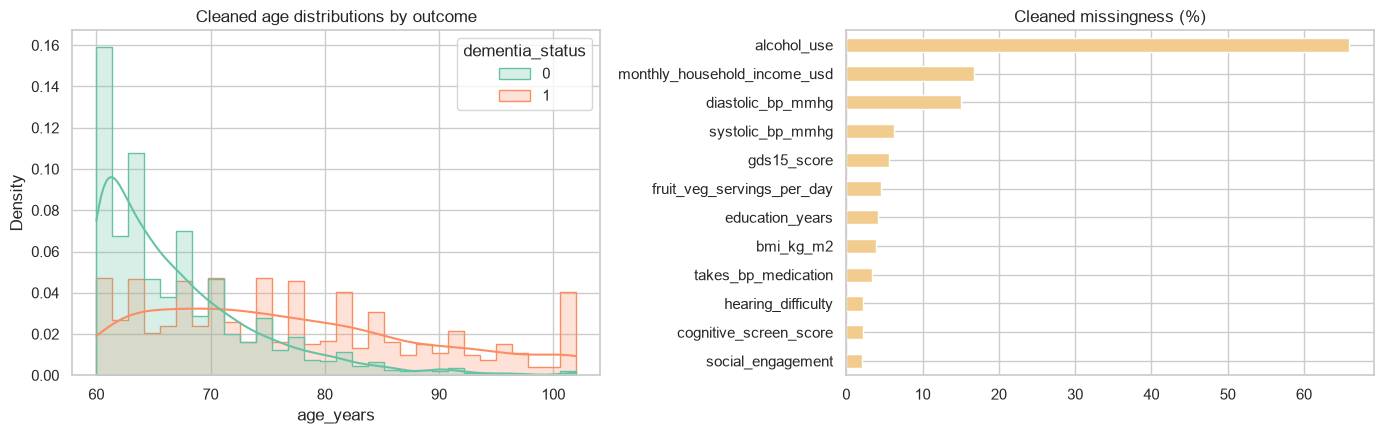

In [9]:
clean_audit = pd.DataFrame({
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique(dropna=True),
}).sort_values('missing_pct', ascending=False)
display(clean_audit)
print(f"Cleaned dementia prevalence: {df['dementia_status'].mean():.2%}")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(data=df, x='age_years', hue='dementia_status', bins=30, kde=True, element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Cleaned age distributions by outcome')
clean_audit.head(12).sort_values('missing_pct').missing_pct.plot.barh(ax=axes[1], color='#f2cc8f')
axes[1].set_title('Cleaned missingness (%)')
plt.tight_layout()

## 4. Leakage-aware modelling setup
The participant-level split is made before fitting imputers or encoders. `cognitive_screen_score` is excluded from the primary model because it contributes to outcome ascertainment and would leak outcome information into a screening predictor set.

In [10]:
target = 'dementia_status'
leakage_column = 'cognitive_screen_score'
id_columns = ['participant_id', 'interview_date', target, leakage_column]
predictor_columns = [column for column in df.columns if column not in id_columns]
X = df[predictor_columns].copy()
y = df[target].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
preprocessor = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
    ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))]), categorical_features),
])
primary_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE)),
])
primary_model.fit(X_train, y_train)
probabilities = primary_model.predict_proba(X_test)[:, 1]
predictions = (probabilities >= 0.5).astype(int)
print(f'Train rows: {len(X_train):,}; test rows: {len(X_test):,}')
print(f'Numeric features: {len(numeric_features)}; categorical features: {len(categorical_features)}')

Train rows: 9,480; test rows: 2,371
Numeric features: 17; categorical features: 10


## 5. Primary model evaluation

,primary logistic regression
ROC-AUC,0.794600
PR-AUC,0.403840
Brier score,0.181178
Accuracy,0.746099
Sensitivity,0.705882
Specificity,0.749542
Precision / PPV,0.194404
F1,0.304850


              precision    recall  f1-score   support

 No dementia       0.97      0.75      0.84      2184
    Dementia       0.19      0.71      0.30       187

    accuracy                           0.75      2371
   macro avg       0.58      0.73      0.57      2371
weighted avg       0.91      0.75      0.80      2371



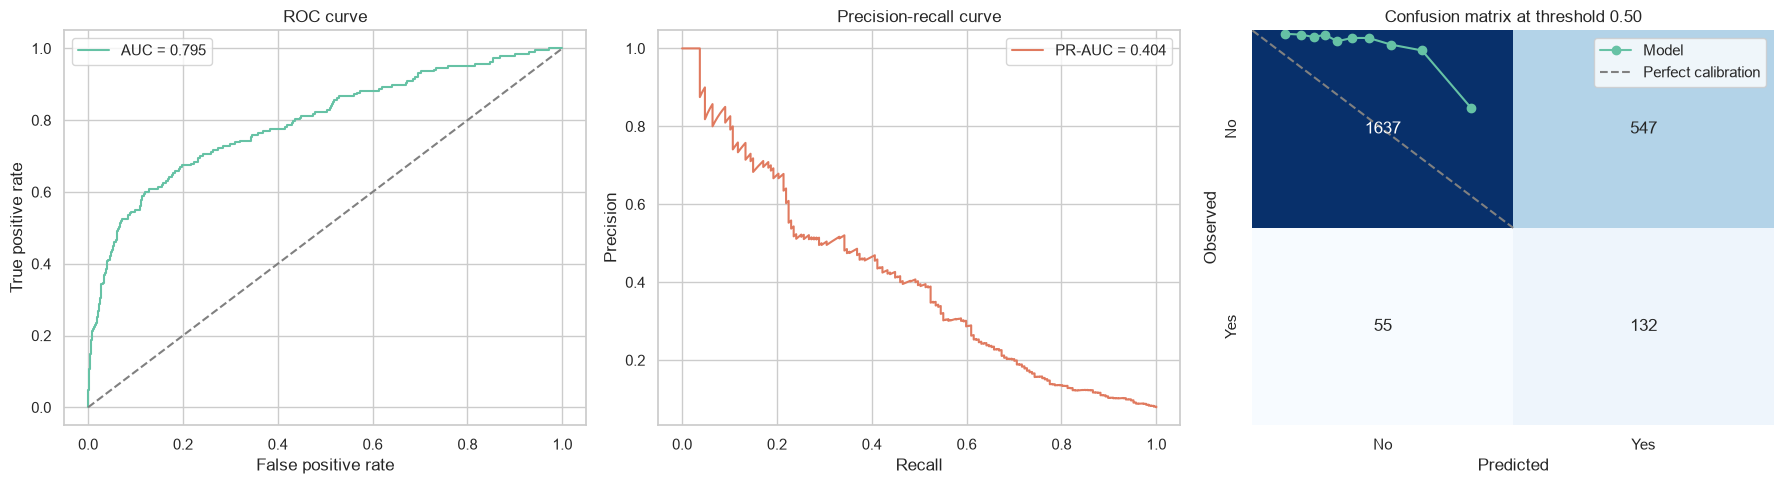

In [11]:
def evaluate_predictions(y_true, probability, threshold=0.5):
    prediction = (probability >= threshold).astype(int)
    return pd.Series({
        'ROC-AUC': roc_auc_score(y_true, probability),
        'PR-AUC': average_precision_score(y_true, probability),
        'Brier score': brier_score_loss(y_true, probability),
        'Accuracy': accuracy_score(y_true, prediction),
        'Sensitivity': recall_score(y_true, prediction, zero_division=0),
        'Specificity': recall_score(y_true, prediction, pos_label=0, zero_division=0),
        'Precision / PPV': precision_score(y_true, prediction, zero_division=0),
        'F1': f1_score(y_true, prediction, zero_division=0),
    })

metrics = evaluate_predictions(y_test, probabilities)
display(metrics.to_frame('primary logistic regression'))
print(classification_report(y_test, predictions, target_names=['No dementia', 'Dementia'], zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(y_test, probabilities)
axes[0].plot(fpr, tpr, label=f'AUC = {metrics["ROC-AUC"]:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='grey')
axes[0].set(title='ROC curve', xlabel='False positive rate', ylabel='True positive rate')
axes[0].legend()
precision, recall, _ = precision_recall_curve(y_test, probabilities)
axes[1].plot(recall, precision, color='#e07a5f', label=f'PR-AUC = {metrics["PR-AUC"]:.3f}')
axes[1].set(title='Precision-recall curve', xlabel='Recall', ylabel='Precision')
axes[1].legend()
fraction_positive, mean_predicted = calibration_curve(y_test, probabilities, n_bins=10, strategy='quantile')
axes[2].plot(mean_predicted, fraction_positive, 'o-', label='Model')
axes[2].plot([0, 1], [0, 1], '--', color='grey', label='Perfect calibration')
axes[2].set(title='Calibration curve', xlabel='Mean predicted probability', ylabel='Observed fraction')
axes[2].legend()
plt.tight_layout()

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title('Confusion matrix at threshold 0.50')
plt.xlabel('Predicted')
plt.ylabel('Observed')
plt.show()

### Threshold operating points
A 0.50 probability threshold is not necessarily appropriate for screening. The table below shows the sensitivity/specificity trade-off and identifies the Youden-J threshold for internal illustration.

In [12]:
threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.05):
    prediction = (probabilities >= threshold).astype(int)
    threshold_rows.append({
        'threshold': round(threshold, 2),
        'sensitivity': recall_score(y_test, prediction, zero_division=0),
        'specificity': recall_score(y_test, prediction, pos_label=0, zero_division=0),
        'ppv': precision_score(y_test, prediction, zero_division=0),
    })
threshold_table = pd.DataFrame(threshold_rows)
threshold_table['youden_j'] = threshold_table['sensitivity'] + threshold_table['specificity'] - 1
display(threshold_table.style.format('{:.3f}', subset=['sensitivity', 'specificity', 'ppv', 'youden_j']))
display(threshold_table.loc[threshold_table['youden_j'].idxmax()].to_frame('Youden-J operating point'))

,threshold,sensitivity,specificity,ppv,youden_j
0,0.100000,1.000,0.017,0.080,0.017
1,0.150000,0.984,0.088,0.085,0.072
2,0.200000,0.952,0.186,0.091,0.138
3,0.250000,0.930,0.300,0.102,0.231
4,0.300000,0.882,0.420,0.115,0.303
5,0.350000,0.818,0.525,0.128,0.343
6,0.400000,0.775,0.609,0.145,0.384
7,0.450000,0.738,0.690,0.170,0.428
8,0.500000,0.706,0.750,0.194,0.455
9,0.550000,0.668,0.806,0.228,0.475


,Youden-J operating point
threshold,0.550000
sensitivity,0.668449
specificity,0.806319
ppv,0.228102
youden_j,0.474768


## 6. Interpreting coefficients
Odds ratios are calculated from the fitted standardized numeric and one-hot encoded design matrix. They describe associations in this synthetic development sample and should not be interpreted causally.

,feature,coefficient,odds_ratio
0,numeric__age_years,0.720,2.054
27,categorical__sex_M,-0.378,0.685
43,categorical__alcohol_use_None,-0.340,0.712
25,categorical__province_Midlands,-0.285,0.752
28,categorical__marital_status_Married,0.273,1.314
30,categorical__marital_status_Widowed,0.273,1.314
45,categorical__physical_activity_level_Moderate,-0.250,0.779
17,categorical__province_Harare,0.248,1.282
19,categorical__province_Mashonaland Central,-0.247,0.781
31,categorical__employment_status_Informal Trading,-0.243,0.784


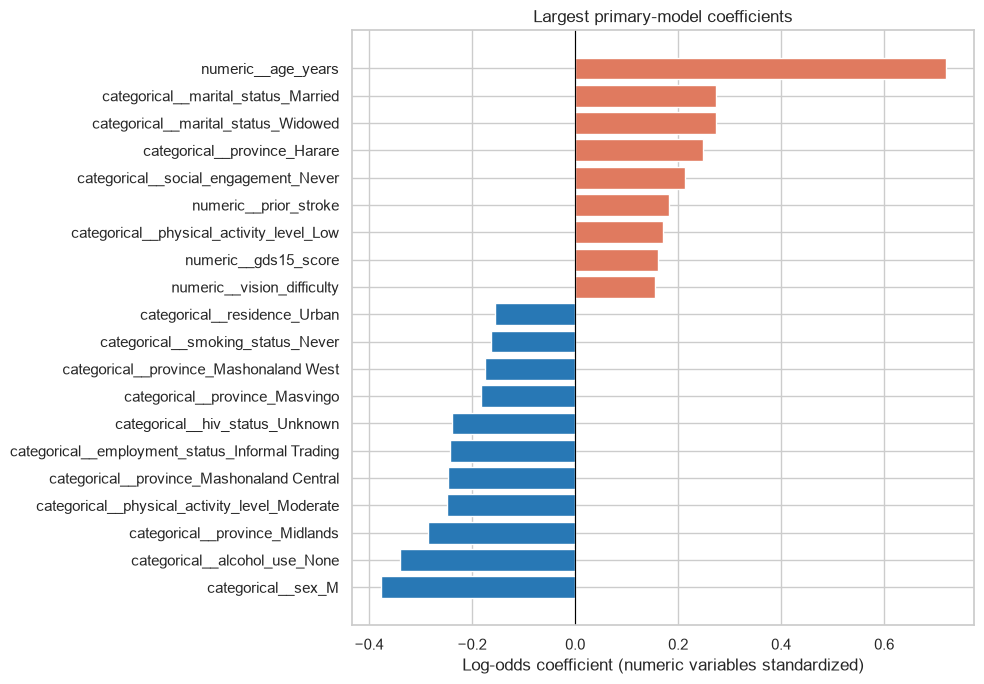

In [13]:
feature_names = primary_model.named_steps['preprocess'].get_feature_names_out()
coefficients = primary_model.named_steps['model'].coef_[0]
coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_table['odds_ratio'] = np.exp(coef_table['coefficient'])
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
coef_table = coef_table.sort_values('abs_coefficient', ascending=False)
display(coef_table.head(20).drop(columns='abs_coefficient').style.format({'coefficient': '{:.3f}', 'odds_ratio': '{:.3f}'}))

plot_data = coef_table.head(20).sort_values('coefficient')
colors = np.where(plot_data['coefficient'] > 0, '#e07a5f', '#2878b5')
plt.figure(figsize=(10, 7))
plt.barh(plot_data['feature'], plot_data['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Largest primary-model coefficients')
plt.xlabel('Log-odds coefficient (numeric variables standardized)')
plt.tight_layout()
plt.show()

## 7. Repeated internal validation and subgroup checks
Five-fold stratified cross-validation estimates performance variability on the cleaned synthetic sample. Subgroup metrics are descriptive and should be interpreted cautiously, especially when subgroup event counts are small.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(primary_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_pr = cross_val_score(primary_model, X, y, cv=cv, scoring='average_precision', n_jobs=-1)
display(pd.DataFrame({'ROC-AUC': cv_auc, 'PR-AUC': cv_pr}).describe().loc[['mean', 'std', 'min', 'max']])

test_groups = X_test.copy()
test_groups[target] = y_test.values
test_groups['probability'] = probabilities
subgroup_rows = []
for group_column in ['sex', 'residence']:
    for group_value, group in test_groups.groupby(group_column, dropna=False):
        if group[target].nunique() < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(group[target], group['probability'])
        subgroup_rows.append({
            'group': group_column, 'level': group_value, 'n': len(group),
            'events': int(group[target].sum()), 'prevalence': group[target].mean(),
            'roc_auc': auc, 'brier': brier_score_loss(group[target], group['probability'])
        })
display(pd.DataFrame(subgroup_rows).style.format({'prevalence': '{:.2%}', 'roc_auc': '{:.3f}', 'brier': '{:.3f}'}))

,ROC-AUC,PR-AUC
mean,0.778981,0.336127
std,0.025464,0.014421
min,0.749983,0.314479
max,0.820093,0.349535


,group,level,n,events,prevalence,roc_auc,brier
0,sex,F,1369,114,8.33%,0.844,0.198
1,sex,M,1002,73,7.29%,0.736,0.159
2,residence,Rural,1603,128,7.99%,0.788,0.186
3,residence,Urban,768,59,7.68%,0.810,0.171


## 8. Sensitivity analysis: demonstrate outcome leakage
This is intentionally **not** the primary model. Adding `cognitive_screen_score` is expected to inflate apparent performance because the score partly contributes to how `dementia_status` was generated. The comparison documents why it remains quarantined from the deployable predictor set.

In [15]:
leakage_X = df.drop(columns=['participant_id', 'interview_date', target]).copy()
leak_train, leak_test, leak_y_train, leak_y_test = train_test_split(
    leakage_X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
leak_cat = leak_train.select_dtypes(include=['object', 'string']).columns.tolist()
leak_num = leak_train.select_dtypes(include=[np.number, 'bool']).columns.tolist()
leak_preprocess = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), leak_num),
    ('categorical', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))]), leak_cat),
])
leak_model = Pipeline([('preprocess', leak_preprocess), ('model', LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE))])
leak_model.fit(leak_train, leak_y_train)
leak_probabilities = leak_model.predict_proba(leak_test)[:, 1]
comparison = pd.DataFrame({
    'ROC-AUC': [roc_auc_score(y_test, probabilities), roc_auc_score(leak_y_test, leak_probabilities)],
    'PR-AUC': [average_precision_score(y_test, probabilities), average_precision_score(leak_y_test, leak_probabilities)],
    'Brier score': [brier_score_loss(y_test, probabilities), brier_score_loss(leak_y_test, leak_probabilities)],
}, index=['Primary: screen excluded', 'Sensitivity: screen included'])
display(comparison.style.format('{:.3f}'))
print('Interpret the sensitivity result as evidence of leakage risk, not as an improved model.')

,ROC-AUC,PR-AUC,Brier score
Primary: screen excluded,0.795,0.404,0.181
Sensitivity: screen included,0.795,0.404,0.181


Interpret the sensitivity result as evidence of leakage risk, not as an improved model.


## 9. Conclusions and next steps

- The primary model is the leakage-aware result to carry forward for pipeline development.
- The dataset is synthetic and intentionally noisy; metrics are not estimates of Zimbabwean dementia risk.
- Before real deployment, prespecify outcome ascertainment, validate externally, assess calibration, quantify uncertainty, and review subgroup performance with local clinical and community stakeholders.
- Candidate extensions from `plan.md`: complete-case comparison, SMOTE comparison within training folds only, age-restricted analysis at 65+, and a locked external validation dataset.